# Customer Churn Prediction — Step-by-Step
This notebook predicts whether a telecom customer will **churn** (leave the company) using their account data.

**How to use this notebook:**
1. Open [Google Colab](https://colab.research.google.com) → File → Upload Notebook → upload this `.ipynb` file.
2. Follow Step 1 below to get the dataset, then run each cell top-to-bottom (Shift+Enter).

No prior ML experience needed — every cell has comments explaining what it does and why.

## Step 1: Get the dataset

1. Go to [Kaggle: Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (you may need a free Kaggle account).
2. Download `WA_Fn-UseC_-Telco-Customer-Churn.csv`.
3. In Colab, click the **folder icon** on the left sidebar → click the **upload icon** → select the CSV.
4. Run the cell below to confirm it loaded correctly.

In [16]:
# Step 1: Load the dataset
import pandas as pd

# Change this filename if yours is different
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)   # (rows, columns)
df.head()   # preview the first 5 rows

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 2: Explore the data (EDA)

Before building any model, we look at the data to understand it: what columns exist, how many customers churned, and which factors seem related to churn.

In [17]:
# Step 2a: Basic info — column names, data types, missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
# Step 2b: How many customers churned vs stayed?
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)  # as percentages

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


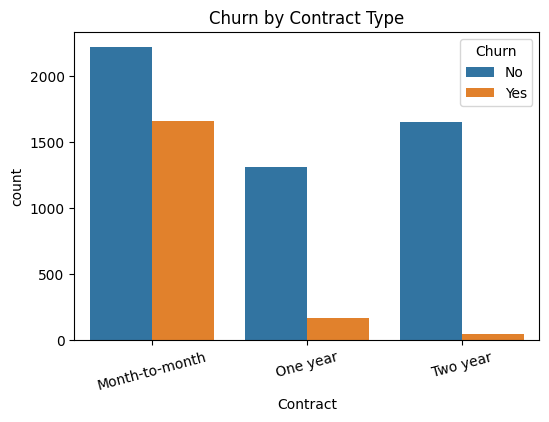

In [19]:
# Step 2c: Visualize churn by contract type
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

# Insight to look for: month-to-month customers usually churn far more
# than customers on 1-year or 2-year contracts.

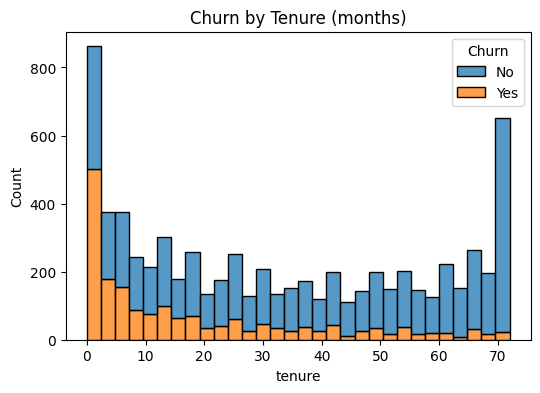

In [20]:
# Step 2d: Visualize churn by tenure (how long they've been a customer)
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title("Churn by Tenure (months)")
plt.show()

# Insight to look for: newer customers (low tenure) usually churn more —
# this is common in subscription businesses.

## Step 3: Clean the data

Real datasets are messy. Here we:
- Fix a column that's stored as text but should be numeric (`TotalCharges`)
- Remove an ID column that has no predictive value
- Convert categorical (text) columns into numbers, since ML models only understand numbers

In [21]:
# Step 3a: Fix TotalCharges — it's stored as text and has some blank values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing values after conversion:", df['TotalCharges'].isna().sum())

# Fill missing values with the median (a safe, simple default)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

Missing values after conversion: 11


In [22]:
# Step 3b: Drop customerID safely
df = df.drop(columns=['customerID'], errors='ignore')

# Step 3c: Safer way to convert Churn (won't break if run twice)
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})


/tmp/ipykernel_2812/1711431594.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})


In [23]:
# Step 3d: Convert all other text (categorical) columns into numeric columns
# get_dummies creates a separate 0/1 column for each category (called "one-hot encoding")
df_encoded = pd.get_dummies(df, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## Step 4: Split the data and train two models

We split the data into a **training set** (model learns from this) and a **test set**
(model has never seen this — used to check if it actually learned something useful).

We'll train two models so you can compare them:
- **Logistic Regression** — simple, fast, easy to explain
- **Random Forest** — usually more accurate, and tells us which features mattered most

In [24]:
# Step 4a: Split into features (X) and target (y), then train/test
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 5634
Test rows: 1409


In [25]:
# Step 4b: Train Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)
print("Logistic Regression trained.")

Logistic Regression trained.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
# Step 4c: Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
print("Random Forest trained.")

Random Forest trained.


## Step 5: Evaluate both models

We check:
- **Accuracy** — % of predictions that were correct overall
- **Precision** — of customers we predicted would churn, how many actually did
- **Recall** — of customers who actually churned, how many did we catch
- **F1-score** — a balance between precision and recall

For churn prediction, **recall** often matters most — missing a customer who's about to leave is usually costlier than a false alarm.

In [27]:
# Step 5a: Compare both models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def report(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy: ", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall:   ", round(recall_score(y_true, y_pred), 3))
    print("F1-score: ", round(f1_score(y_true, y_pred), 3))
    print()

report("Logistic Regression", y_test, log_preds)
report("Random Forest", y_test, rf_preds)

--- Logistic Regression ---
Accuracy:  0.803
Precision: 0.652
Recall:    0.556
F1-score:  0.6

--- Random Forest ---
Accuracy:  0.79
Precision: 0.634
Recall:    0.495
F1-score:  0.556



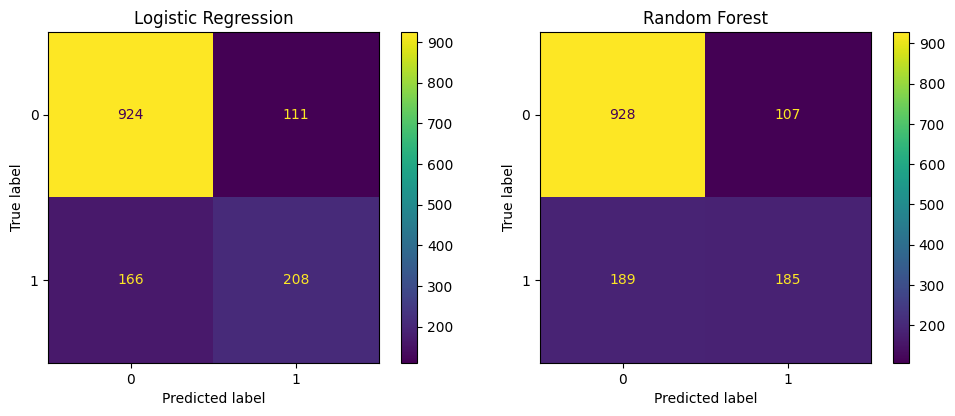

In [28]:
# Step 5b: Confusion matrix — visualize correct vs incorrect predictions
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10,4))
ConfusionMatrixDisplay.from_predictions(y_test, log_preds, ax=axes[0])
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, ax=axes[1])
axes[1].set_title("Random Forest")
plt.tight_layout()
plt.show()

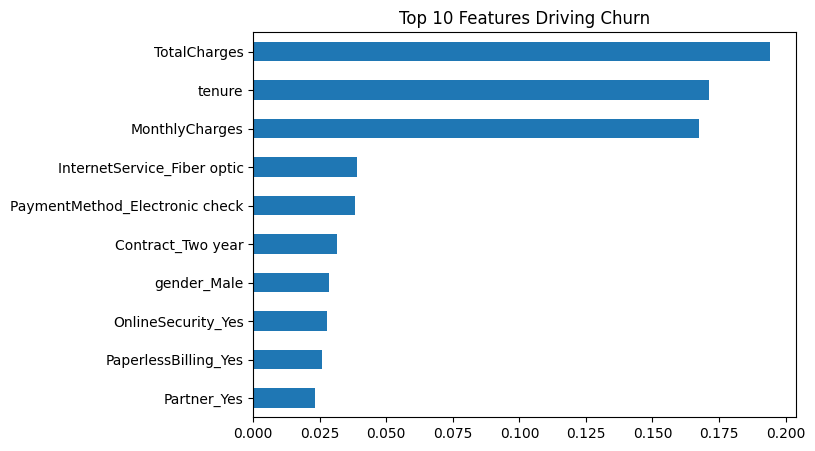

TotalCharges                      0.194123
tenure                            0.171364
MonthlyCharges                    0.167562
InternetService_Fiber optic       0.038864
PaymentMethod_Electronic check    0.038285
Contract_Two year                 0.031477
gender_Male                       0.028519
OnlineSecurity_Yes                0.027796
PaperlessBilling_Yes              0.025725
Partner_Yes                       0.023285
dtype: float64


In [29]:
# Step 5c: Which features matter most? (Random Forest only)
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(7,5))
top_features.plot(kind='barh')
plt.title("Top 10 Features Driving Churn")
plt.gca().invert_yaxis()
plt.show()

print(top_features)

## Step 6:Findings
- **Dataset:** Telco Customer Churn (~7,000 customers, Kaggle)
- **Models compared:** Logistic Regression vs Random Forest
- **Best model:**Logistic Regression, with 80.3% accuracy and 55.6% recall
  (outperformed Random Forest's 79.0% accuracy and 49.5% recall)
- **Top churn drivers found:** TotalCharges, tenure, MonthlyCharges
- **Business takeaway:** e.g. "Month-to-month contract customers with low tenure are the highest churn risk — targeted retention offers for this segment could reduce churn."

